In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
def generate_test_data_from_image():
    """
    Reads the source image, converts it to binarized 64x64 data.
    If the image is not found, falls back to a synthetic circle.
    Writes the interleaved imager_test_data.hex file.
    """
    image_path = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/source_image.png"
    # 1. Load the image OR generate synthetic fallback
    if os.path.exists(image_path):
        print(f"Loading '{image_path}'...")
        # Convert to Grayscale ('L') and force to 64x64
        img_pil = Image.open(image_path).convert('L').resize((64, 64))
        # Binarize: Pixels > 128 become 1 (White/ON), otherwise 0 (Black/OFF)
        img = (np.array(img_pil) > 128).astype(int)
    else:
        print(f"[WARNING] Could not find image at: {image_path}")
        print(" -> Falling back to synthetic 64x64 circle pattern.")
        img = np.zeros((64, 64), dtype=int)
        for y in range(64):
            for x in range(64):
                if (x - 32)**2 + (y - 32)**2 < 20**2:
                    img[y, x] = 1
            
    # 2. Separate into ON events (pixels == 1) and OFF events (pixels == 0)
    on_events = (img == 1).astype(int)
    off_events = (img == 0).astype(int)
    
    # 3. Interleave rows and write to hex file for Verilog
    filename = "imager_test_data.hex"
    with open(filename, "w") as f:
        for row in range(64):
            # Pack 64 pixels into a 64-bit integer
            on_val = 0
            off_val = 0
            for col in range(64):
                on_val  |= (int(on_events[row, col]) << (63 - col))
                off_val |= (int(off_events[row, col]) << (63 - col))
                
            f.write(f"{on_val:016X}\n")
            f.write(f"{off_val:016X}\n")
            
    print(f"Successfully generated 128 rows of 64-bit hex data to '{filename}'!")

    # Return the generated arrays so the parser can compare them later
    return img, on_events, off_events

In [6]:

def parse_data_from_roic(original_img, expected_on, expected_off):
    """
    Parses sim_output.txt, reconstructs the arrays, compares them 
    against the expected inputs, and displays the 2x2 verification plot.
    """
    parsed_on = np.zeros((64, 64), dtype=int)
    parsed_off = np.zeros((64, 64), dtype=int)
    
    on_row_idx = 0
    off_row_idx = 0
    
    filepath = "sim_output.txt" # generated by roic_top_tb.sv

    if not os.path.exists(filepath):
        print(f"\nError: '{filepath}' not found.")
        print("Make sure you run the SystemVerilog ROIC simulation first!")
        return
        
    print(f"Parsing '{filepath}'...")
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            # Read the 17-character hex string as a base-16 integer
            val = int(line, 16)
            
            # Shift and mask to decouple the event flag and the array data
            event_flag = (val >> 64) & 0x3  # The top 2 bits
            data_64bit = val & 0xFFFFFFFFFFFFFFFF  # The bottom 64 bits
            
            # Unpack the 64-bit integer back into an array of 64 individual pixels
            row_pixels = [(data_64bit >> (63 - col)) & 1 for col in range(64)]
            
            if event_flag == 2:   # 2'b10 (ON DETECT)
                if on_row_idx < 64:
                    parsed_on[on_row_idx, :] = row_pixels
                    on_row_idx += 1
                    
            elif event_flag == 1: # 2'b01 (OFF DETECT)
                if off_row_idx < 64:
                    parsed_off[off_row_idx, :] = row_pixels
                    off_row_idx += 1

    print(f" -> Captured {on_row_idx} ON rows and {off_row_idx} OFF rows from RTL output.")

    # =======================================================================
    # AUTOMATED DATA INTEGRITY CHECK
    # =======================================================================
    on_match = np.array_equal(expected_on, parsed_on)
    off_match = np.array_equal(expected_off, parsed_off)
    
    print("\n==========================================================")
    if on_match and off_match:
        print(" [SUCCESS] ROIC OUTPUT PERFECTLY MATCHES ORIGINAL IMAGE!")
    else:
        print(" [FATAL ERROR] ROIC OUTPUT MISMATCH DETECTED!")
        if not on_match: print("  -> ON events do not match.")
        if not off_match: print("  -> OFF events do not match.")
    print("==========================================================\n")

    # =======================================================================
    # RECONSTRUCT & PLOT
    # =======================================================================
    # Reconstruct the image (ON events perfectly represent the BW image's '1's)
    reconstructed = parsed_on | (parsed_off * 0)

    fig, axes = plt.subplots(2, 2, figsize=(11, 11))
    fig.canvas.manager.set_window_title('ROIC Digital Twin Verification')
    
    axes[0, 0].imshow(original_img, cmap='gray')
    axes[0, 0].set_title("1. Original Image (Input)", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(parsed_on, cmap='gray')
    title_on = f"2. Parsed ON Events (Match: {'YES' if on_match else 'NO'})"
    axes[0, 1].set_title(title_on, color='green' if on_match else 'red', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(reconstructed, cmap='gray')
    axes[1, 0].set_title("3. ROIC Reconstructed Output", fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(parsed_off, cmap='gray')
    title_off = f"4. Parsed OFF Events (Match: {'YES' if off_match else 'NO'})"
    axes[1, 1].set_title(title_off, color='green' if off_match else 'red', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [7]:
# 1. Generate the stimulus file (run this BEFORE Verilog Simulation)
img, expected_on, expected_off = generate_test_data_from_image()

Loading '/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/source_image.png'...
Successfully generated 128 rows of 64-bit hex data to 'imager_test_data.hex'!


Parsing 'sim_output.txt'...
 -> Captured 64 ON rows and 64 OFF rows from RTL output.

 [SUCCESS] ROIC OUTPUT PERFECTLY MATCHES ORIGINAL IMAGE!



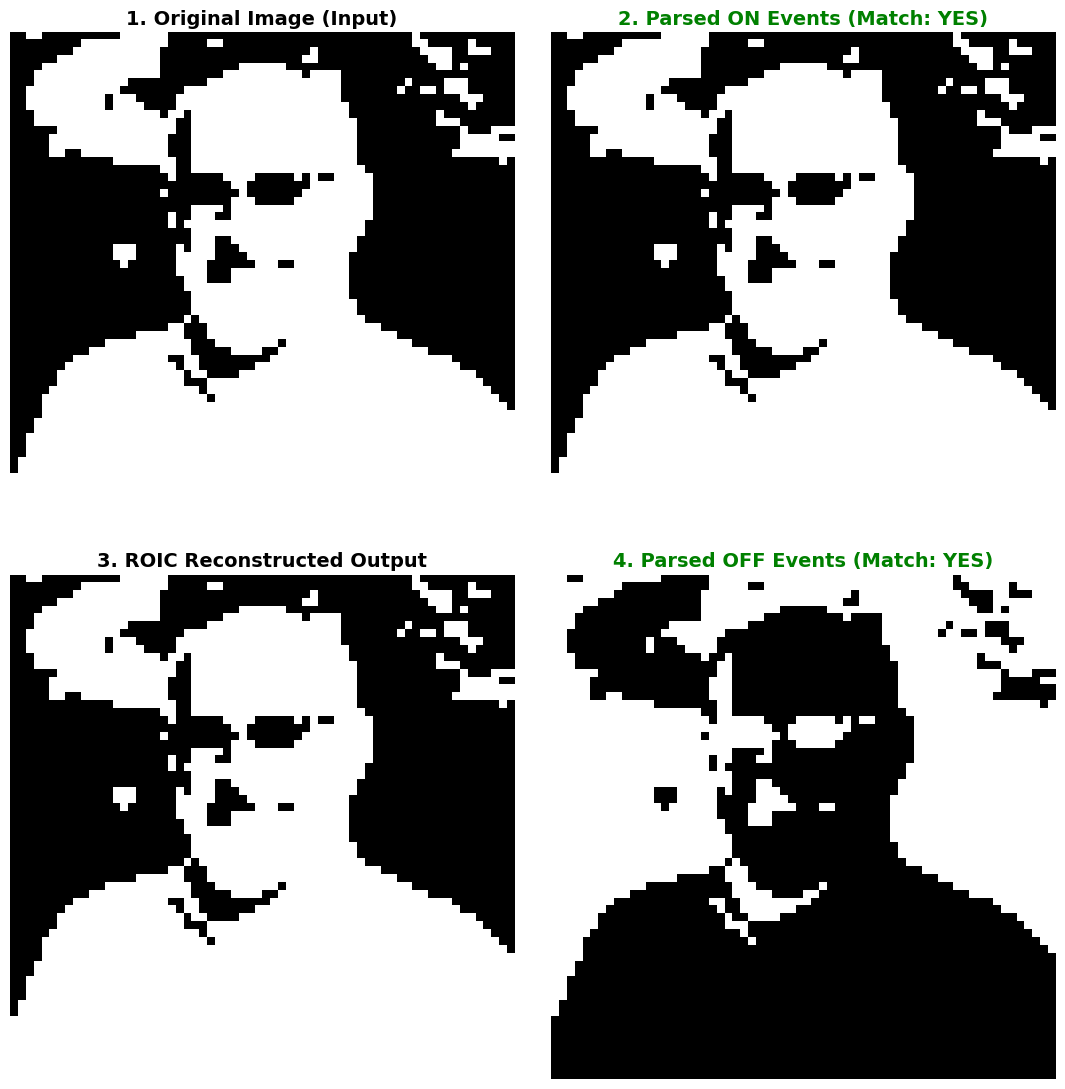

In [8]:
# 2. Parse the output and compare (run this AFTER Verilog Simulation)
if img is not None:
    parse_data_from_roic(img, expected_on, expected_off)